# Análisis salarial del sector IT argentino — Sysarmy 2026
## Parte 1 · Curación y análisis exploratorio

*Realizado en el marco de la Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones (FaMAF, UNC).*

In [15]:
import io
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_context('talk')

## Los datos
Encuesta abierta y voluntaria de sueldos de Sysarmy (edición 2026), ~4.900 respuestas del sector IT argentino. Cada fila es una persona; las columnas cubren salario bruto y neto, seniority, modalidad de trabajo, tecnologías y datos demográficos.

In [16]:
url = 'https://raw.githubusercontent.com/DiploDatos/AnalisisyVisualizacion/master/sysarmy_survey_2026_processed.csv'
df = pd.read_csv(url)

In [17]:
df[:10]

,work_province,work_dedication,work_contract_type,salary_monthly_BRUTO,salary_monthly_NETO,salary_in_usd,salary_last_dollar_value,salary_has_bonus,salary_bonus_tied_to,salary_inflation_adjustment,...,salary_on_call_duty_charge,aclara_el_numero_que_ingresaste_en_el_campo_anterior,salir_o_seguir_contestando_sobre_estudios,profile_age,profile_gender,profile_previous_survey,company_best_companies,sueldo_dolarizado,work_seniority,_sal
0,Mendoza,Full-Time,Staff (planta permanente),3000000.0,2400000.0,Mi sueldo está dolarizado (pero cobro en moned...,1300,No,Performance individual,No,...,NaN,NaN,NaN,45,Mujer Cis,Sí,NaN,True,Senior,3000000.0
1,Santa Fe,Full-Time,Contractor,5000000.0,5000000.0,Cobro todo el salario en dólares,1400,No,No recibo bono,No,...,NaN,NaN,NaN,50,Mujer Cis,Sí,NaN,True,Senior,5000000.0
2,Buenos Aires,Full-Time,Tercerizado (trabajo a través de consultora o ...,4600000.0,3600000.0,Cobro parte del salario en dólares,1436,No,No recibo bono,Uno,...,0.0,Porcentaje de mi sueldo bruto,Terminar encuesta,36,Mujer Cis,Sí,NaN,True,Senior,4600000.0
3,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),7800000.0,6000000.0,Cobro parte del salario en dólares,1470,3+ sueldos,Mix de las anteriores,No,...,NaN,NaN,NaN,60,Hombre Cis,Sí,NaN,True,Senior,7800000.0
4,Jujuy,Full-Time,Contractor,3500000.0,3200000.0,Cobro todo el salario en dólares,NaN,No,No recibo bono,No,...,NaN,NaN,NaN,29,Hombre Cis,Sí,Nose,True,Semi-Senior,3500000.0
5,Corrientes,Part-Time,Contractor,400000.0,400000.0,Mi sueldo está dolarizado (pero cobro en moned...,1450,No,No recibo bono,No,...,0.0,Porcentaje de mi sueldo bruto,Terminar encuesta,22,Hombre Cis,No,"Devligths, Banco de Corrientes, Poder Judicial",True,Junior,400000.0
6,Ciudad Autónoma de Buenos Aires,Full-Time,Contractor,8460000.0,7200000.0,Cobro todo el salario en dólares,6000,De uno a tres sueldos,Performance de la compañía,Uno,...,0.0,Bruto,Responder sobre mis estudios,47,Hombre Cis,Sí,"COELSA, Mercado Libre, Santander Tecnología",True,Senior,8460000.0
7,Buenos Aires,Full-Time,Contractor,6400000.0,6400000.0,Cobro todo el salario en dólares,NaN,No,No recibo bono,No,...,10.0,Porcentaje de mi sueldo bruto,Responder sobre mis estudios,29,Hombre Cis,Sí,NaN,True,Semi-Senior,6400000.0
8,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),3000000.0,2500000.0,Mi sueldo está dolarizado (pero cobro en moned...,no está dolarizado cobro en peso.,Menos de un sueldo,Performance de la compañía,Más de tres,...,0.0,Porcentaje de mi sueldo bruto,Terminar encuesta,40,Mujer Cis,Sí,"Lemón, Salesforce y otras",True,Semi-Senior,3000000.0
9,Ciudad Autónoma de Buenos Aires,Full-Time,Contractor,6075000.0,6075000.0,Cobro todo el salario en dólares,NaN,No,No recibo bono,Uno,...,NaN,NaN,NaN,30,Mujer Cis,Sí,NaN,True,Senior,6075000.0


In [ ]:
cols = ['salary_monthly_NETO', 'salary_monthly_BRUTO', 'profile_age',
        'work_seniority', 'work_work_modality', 'profile_studies_level', 'profile_gender']
n = len(df)
print(f"Filas totales: {n}\n")
for c in cols:
    na = df[c].isna().sum()
    ceros = (df[c] == 0).sum() if df[c].dtype.kind in 'if' else '-'
    print(f"{c:28s}  NA: {na:5d} ({na/n:5.1%})   ceros: {ceros}")

s = df['salary_monthly_NETO']
print(f"\nsalarios < 100k (errores/no comparables): {(s < 100000).sum()}")
print(f"salarios == 0: {(s == 0).sum()}")

Filas totales: 4939

salary_monthly_NETO           NA:   222 ( 4.5%)   ceros: 0
salary_monthly_BRUTO          NA:     0 ( 0.0%)   ceros: 0
profile_age                   NA:     0 ( 0.0%)   ceros: 0
work_seniority                NA:     0 ( 0.0%)   ceros: -
work_work_modality            NA:     0 ( 0.0%)   ceros: -
profile_studies_level         NA:  3178 (64.3%)   ceros: -
profile_gender                NA:     1 ( 0.0%)   ceros: -

salarios < 100k (errores/no comparables): 8
salarios == 0: 0


In [19]:
print(df['salary_monthly_NETO'].dropna().sort_values(ascending=False).head(20).values)

[6.53388190e+08 4.11428617e+08 1.45178708e+08 9.50000000e+07
 8.00000000e+07 7.60000000e+07 6.00000000e+07 5.50000000e+07
 3.60000000e+07 3.50000000e+07 3.20000000e+07 3.20000000e+07
 3.00000000e+07 2.60000000e+07 2.50000000e+07 2.40000000e+07
 2.30000000e+07 2.20000000e+07 2.18030000e+07 1.90000000e+07]


# ¿Qué lenguajes se asocian a los mejores salarios?
Seleccionamos las columnas y filas relevantes, definimos una métrica de comparación y la analizamos combinando visualizaciones, estadística descriptiva y probabilidades.

In [20]:
relevant_columns = ['tools_programming_languages', 'salary_monthly_NETO', 'work_dedication']
salary_col = 'salary_monthly_NETO'

Veamos la estadistica descriptiva de la columna `salary_monthly_NETO`

In [21]:
df[salary_col].describe()

count    4.717000e+03
mean     3.599215e+06
std      1.183755e+07
min      1.600000e+00
25%      1.850000e+06
50%      2.750000e+06
75%      4.000000e+06
max      6.533882e+08
Name: salary_monthly_NETO, dtype: float64

La estadística descriptiva inicial revela problemas evidentes: salario mínimo de $ \$1.60 $  y máximo de $ \$653M $, con una desviación estándar ($ \$11.8M $) que excede la media $ (\$3.6M) $, indicador clásico de distribución extremadamente sesgada por outliers. Procedemos a filtrar.

En principio eliminamos los `NaN` en la columna del salario. Ademas elegimos la subpoblacion de empleados Full Time, ya que la cantidad de valores correspondiente a Part Time no es representativo del dataset.

In [22]:
df['work_dedication'].value_counts()

work_dedication
Full-Time    4724
Part-Time     215
Name: count, dtype: int64

La mayoría de las respuestas son `Full-Time`; el resto `Part-Time` representa una sub-población distinta no comparable

In [ ]:
df = df.dropna(subset=[salary_col])

df = df[df['work_dedication'] != 'Part-Time']

Para separar los errores y valores no comparables de la cola legítima de la distribución, en lugar de elegir percentiles a mano aplicamos una regla estadística definida: las **vallas de Tukey (1.5·IQR)**, el mismo criterio que define los bigotes de un boxplot. Ahora bien, la distribución de salarios es fuertemente asimétrica a derecha (aproximadamente log-normal). Aplicar la regla directamente sobre la escala cruda marcaría como atípica buena parte de la cola alta legítima —falsos positivos—, porque la valla asume una distribución aproximadamente simétrica. Por eso aplicamos Tukey sobre **log10(salario)**: en esa escala la distribución se simetriza y la regla detecta solo lo genuinamente anómalo.

In [24]:
np.log10(df[salary_col]).describe()

count    4516.000000
mean        6.440716
std         0.316993
min         0.204120
25%         6.278754
50%         6.447158
75%         6.603714
max         8.815171
Name: salary_monthly_NETO, dtype: float64

Calculamos los cuartiles Q1 y Q3 sobre log10(salario), obtenemos el rango intercuartílico (IQR = Q3 − Q1) y definimos las cotas como Q1 − 1.5·IQR y Q3 + 1.5·IQR, devueltas a la escala original con la transformación inversa. Todo salario fuera de ese rango se descarta. Usamos el factor **1.5** (definición estándar de outlier) y no 3, porque buscamos remover también los errores moderados —valores en USD declarados como ARS, en el orden de las decenas de millones— y no únicamente los extremos.

In [25]:
log_sal = np.log10(df[salary_col])
q1, q3 = log_sal.quantile([0.25, 0.75])
iqr = q3 - q1
low, high = 10**(q1 - 1.5 * iqr), 10**(q3 + 1.5 * iqr)
print(f"Cota inferior (Tukey sobre log10): ${low:,.0f}")
print(f"Cota superior (Tukey sobre log10): ${high:,.0f}")

df1 = df[df[salary_col].between(low, high)].copy()
print(f"Antes: {len(df)} | Después: {len(df1)} | "
      f"Eliminados: {len(df) - len(df1)} ({(len(df) - len(df1)) / len(df) * 100:.1f}%)")
df1[salary_col].describe()

Cota inferior (Tukey sobre log10): $618,463
Cota superior (Tukey sobre log10): $12,335,410
Antes: 4516 | Después: 4422 | Eliminados: 94 (2.1%)


count    4.422000e+03
mean     3.258062e+06
std      1.889779e+06
min      6.193050e+05
25%      1.943282e+06
50%      2.800000e+06
75%      4.000000e+06
max      1.200000e+07
Name: salary_monthly_NETO, dtype: float64

Las cotas resultantes son aproximadamente **$618,463** y **$12,335,410** (valores exactos en la salida de la celda anterior). Por debajo de la cota inferior los montos son incompatibles con un empleo IT full-time, lo que apunta a errores de carga o jornadas no comparables. Por encima de la cota superior, el top-20 de salarios confirma que se trata de valores declarados en USD pero cargados como ARS (hasta 653 millones). A diferencia de un corte por percentiles fijos elegidos a mano, estas cotas surgen de una regla estándar aplicada en la escala donde la distribución es simétrica: son reproducibles y no dependen de un umbral arbitrario. El filtrado conserva el **94%** de las muestras.

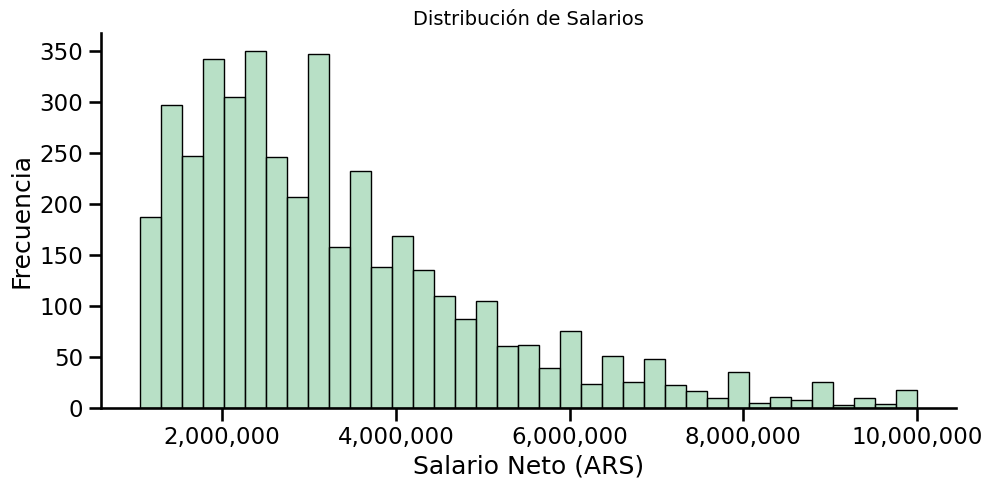

In [ ]:
g = sns.displot(
    df1[salary_col],
    aspect=2,
    color="#A0D6B4",
    edgecolor="black",
    linewidth=1,
    #log_scale=(True, False)
)

g.set_axis_labels("Salario Neto (ARS)", "Frecuencia")

plt.title("Distribución de Salarios", fontsize=14)

g.ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.show()

### Conteo de frecuencias de los lenguajes de programación

La columna que contiene información sobre los lenguajes de programación utilizados es `tools_programming_languages`. Sus valores son strings con los lenguajes seleccionados separados por comas.



In [14]:
df1.tools_programming_languages[:6]

0    .NET, C#, CSS, Go, HTML, Java, Javascript, SQL
1                   .NET, C#, HTML, Javascript, SQL
2                                           Go, SQL
3                         Ninguno de los anteriores
4                                Bash/Shell, Python
6    .NET, C#, CSS, Go, HTML, Java, Javascript, SQL
Name: tools_programming_languages, dtype: str

El procesamiento de la columna tools_programming_languages consta de tres pasos: 
1. Parseamos cada string de respuesta en una lista de lenguajes individuales 
2. Explotamos el DataFrame de modo que cada par (encuestado, lenguaje) ocupe su propia fila 
3. Calculamos la frecuencia de aparición de cada lenguaje en la muestra.

In [113]:
# Convierte el string de lenguajes separados por comas en una lista limpia,
# descartando la opción "Ninguno de los anteriores".
def split_languages(languages_str):
    if not isinstance(languages_str, str):
        return []
    return [
        lang.strip().lower()
        for lang in languages_str.split(',')
        if lang.strip().lower() != 'ninguno de los anteriores'
    ]

# Generamos la columna con la lista de lenguajes por encuestado.
df1.loc[:, 'cured_programming_languages'] = df1.tools_programming_languages\
    .apply(split_languages)
if 'cured_programming_languages' not in relevant_columns:
    relevant_columns.append('cured_programming_languages')

# Construimos el DataFrame en forma "larga": una fila por par (encuestado, lenguaje).
# Solo conservamos las columnas relevantes para el análisis posterior.
df_lang = df1[relevant_columns].explode('cured_programming_languages')\
    .rename(columns={'cured_programming_languages': 'programming_language'})
df_lang[:5]

,tools_programming_languages,salary_monthly_NETO,work_dedication,programming_language
0,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,.net
0,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,c#
0,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,css
0,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,go
0,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,html


El resultado es un DataFrame donde cada fila representa un par (encuestado, lenguaje). Una respuesta que mencionaba $N$ lenguajes se replicó $N$ veces manteniendo constantes las demás columnas. Esta forma "larga" del DataFrame facilita los análisis agrupados por lenguaje en los pasos siguientes.

**Limitación adicional (no-independencia de observaciones):** cuando se
transforma el dataset al formato "largo" (una fila por par
encuestado–lenguaje), las observaciones dejan de ser independientes. Un
encuestado que conoce N lenguajes aparece N veces con su salario replicado,
por lo que las comparaciones entre lenguajes incluyen subpoblaciones
solapadas (e.g., la mayoría de los respondents de Java también responden
SQL). Esto puede inflar la significancia estadística aparente en cualquier
test que asuma independencia (t-test, Mann–Whitney, Kruskal–Wallis). Para
un análisis inferencial más riguroso correspondería usar modelos mixtos
con el encuestado como efecto aleatorio, o restringir las comparaciones a
grupos disjuntos. Las conclusiones de este análisis deben interpretarse
como descriptivas de la asociación entre lenguajes y salarios en la
muestra observada.

In [114]:
language_count = df_lang['programming_language'].value_counts()\
    .reset_index()\
    .rename(columns={'programming_language': 'language', 'count': 'frequency'})
language_count[:10]

,language,frequency
0,sql,1910
1,javascript,1577
2,python,1526
3,html,1170
4,typescript,966
5,bash/shell,767
6,css,736
7,java,693
8,.net,478
9,php,474


Filtramos los lenguajes con menos de 100 apariciones en la muestra. Con tamaños muestrales tan chicos, los estadísticos resultantes (media, mediana, percentiles) se vuelven inestables: un solo encuestado con salario atípico puede mover la media del grupo varios cientos de miles de pesos. El umbral de 100 es arbitrario pero conservador, y asegura que las comparaciones posteriores entre lenguajes tengan una base muestral comparable.

In [115]:
languages_more_than_100_freq = language_count[language_count['frequency'] > 100]
display(languages_more_than_100_freq)

,language,frequency
0,sql,1910
1,javascript,1577
2,python,1526
3,html,1170
4,typescript,966
5,bash/shell,767
6,css,736
7,java,693
8,.net,478
9,php,474


## Selección de lenguajes a comparar
Nos quedamos con los lenguajes que superan el umbral de frecuencia, para que cada comparación tenga una base muestral suficiente.

In [116]:
top15_languages = [
    'sql', 'javascript', 'python', 'html', 'typescript',
    'bash/shell', 'css', 'java', 'php', '.net',
    'c#', 'go', 'kotlin', 'vba', 'c++'
]

top10_languages = [
    'python', 'sql', 'javascript', 'html',
    'bash/shell', 'typescript', 'css', 'java', 'php', '.net'
]

        RESUMEN DEL FILTRADO (top 15)       
Muestras originales:      12,814
Muestras eliminadas:       1,545  (12.1%)
Muestras conservadas:     11,269  (87.9%)


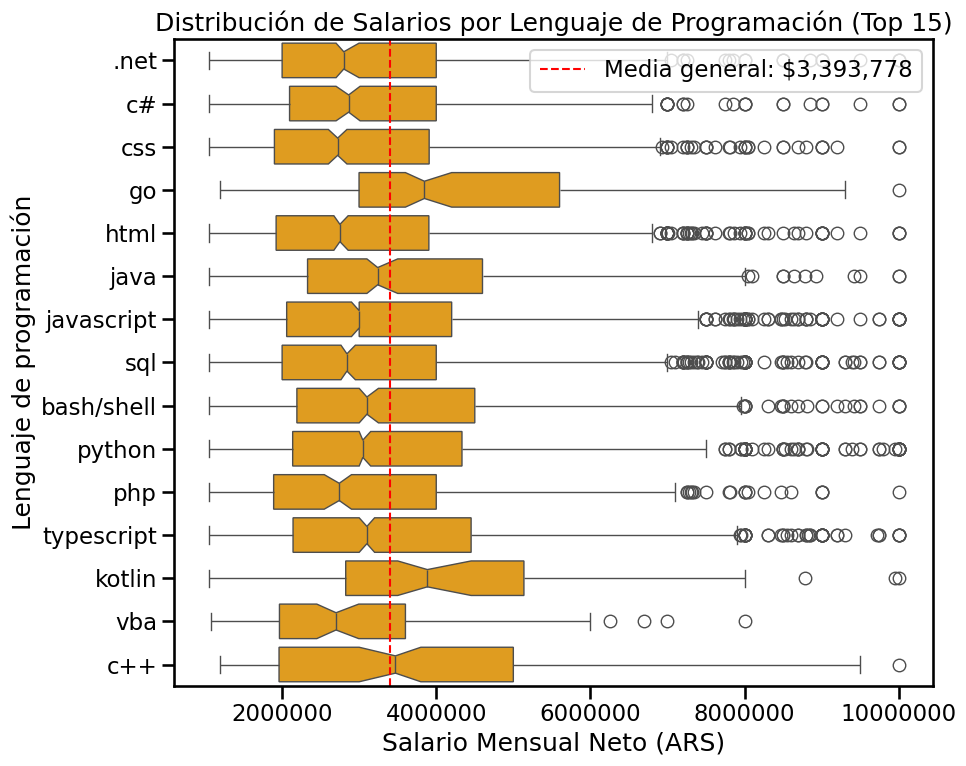

In [ ]:
df_plot = df_lang[df_lang['programming_language'].isin(top15_languages)].copy()

total        = len(df_lang)
filtrado_15  = len(df_plot)
eliminados_15 = total - filtrado_15
pct_15       = (eliminados_15 / total) * 100

print(f"  {'RESUMEN DEL FILTRADO (top 15)':^42}")
print("=" * 46)
print(f"Muestras originales:  {total:>10,}")
print(f"Muestras eliminadas:  {eliminados_15:>10,}  ({pct_15:.1f}%)")
print(f"Muestras conservadas: {filtrado_15:>10,}  ({100 - pct_15:.1f}%)")
print("=" * 46)

fig, ax = plt.subplots(figsize=(10, 8))

sns.boxplot(
    data=df_plot,
    y='programming_language',
    x=salary_col,
    color='orange',
    notch=True,
    bootstrap=1000,
    ax=ax,
)

media_general = df_lang[salary_col].mean()
ax.axvline(
    x=media_general,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Media general: ${media_general:,.0f}',
)

ax.legend(loc='upper right')
ax.ticklabel_format(style='plain', axis='x')
ax.set_ylabel('Lenguaje de programación')
ax.set_xlabel('Salario Mensual Neto (ARS)')
ax.set_title('Distribución de Salarios por Lenguaje de Programación (Top 15)')
plt.tight_layout()
plt.show()

Kotlin, Go y C++ presentan medianas superiores al resto, pero sus tamaños
muestrales (125, 247 y 118 observaciones respectivamente) son demasiado
reducidos para sostener comparaciones robustas: un puñado de valores atípicos
puede desplazar la media varios cientos de miles de pesos. Por eso restringimos
el análisis a los 10 lenguajes más usados, todos con más de 490 observaciones.

In [ ]:
df_top10 = df_lang[df_lang['programming_language'].isin(top10_languages)].copy()

filtrado_10  = len(df_top10)
eliminados_10 = total - filtrado_10
pct_10       = (eliminados_10 / total) * 100

print(f"  {'RESUMEN DEL FILTRADO (top 10)':^42}")
print("=" * 46)
print(f"Muestras originales:  {total:>10,}")
print(f"Muestras eliminadas:  {eliminados_10:>10,}  ({pct_10:.1f}%)")
print(f"Muestras conservadas: {filtrado_10:>10,}  ({100 - pct_10:.1f}%)")
print("=" * 46)

        RESUMEN DEL FILTRADO (top 10)       
Muestras originales:      12,814
Muestras eliminadas:       2,517  (19.6%)
Muestras conservadas:     10,297  (80.4%)


Para ayudar a responder la pregunta elegimos realizar una combinacion de las 3 posibilidades.

En principio recurrimos a la visualizacion mediante un boxplot ordenando los lenguajes basandonos en la mediana.

Estadística Descriptiva por Lenguaje (Ordenado por Mediana):


,Mediana,Media,Desvio_Estandar,Top_10_Porciento
programming_language,,,,
java,"3,240,000","3,608,055","1,698,919","6,000,000"
bash/shell,"3,100,000","3,552,485","1,817,384","6,000,000"
typescript,"3,100,000","3,564,686","1,919,387","6,406,250"
python,"3,047,190","3,503,523","1,845,626","6,100,000"
javascript,"3,000,000","3,392,360","1,811,460","6,000,000"
sql,"2,841,000","3,264,286","1,707,849","5,600,000"
.net,"2,800,000","3,245,120","1,691,940","5,515,000"
html,"2,750,000","3,179,058","1,692,747","5,650,000"
php,"2,741,148","3,203,789","1,767,486","6,000,000"


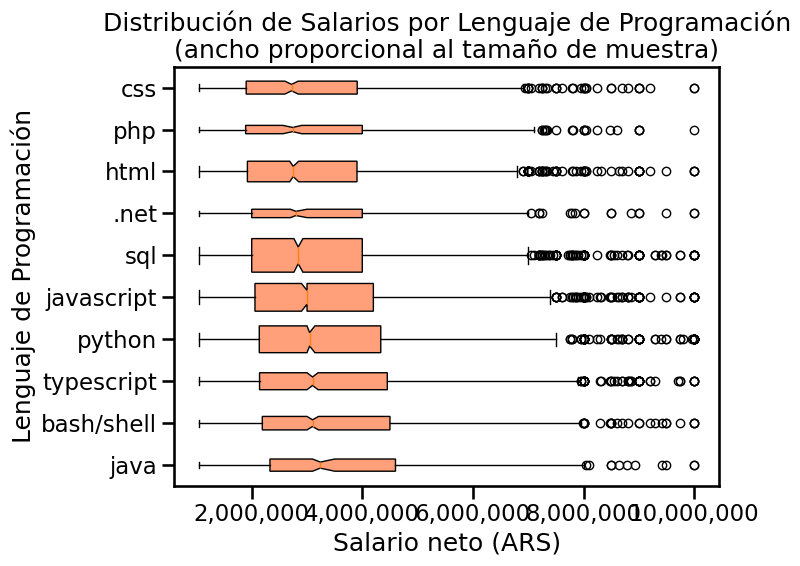

In [ ]:
def percentil_90(x):
    return x.quantile(0.9)

resumen_stats = df_top10.groupby('programming_language')[salary_col].agg(
    Mediana='median',
    Media='mean',
    Desvio_Estandar='std',
    Top_10_Porciento=percentil_90
).sort_values(by='Mediana', ascending=False)

print("Estadística Descriptiva por Lenguaje (Ordenado por Mediana):")
display(resumen_stats.style.format("{:,.0f}"))

fig, ax = plt.subplots(figsize=(8, 6))

langs_ordenados = resumen_stats.index.tolist()

conteos = df_top10.groupby('programming_language')[salary_col].count()
max_conteo = conteos.max()
widths = [conteos[lang] / max_conteo * 0.8 for lang in langs_ordenados]  

datos = [df_top10[df_top10['programming_language'] == lang][salary_col].values
         for lang in langs_ordenados]

bp = ax.boxplot(datos,
                vert=False,          
                patch_artist=True,   
                widths=widths,
                notch=True,
                bootstrap=1000)

for patch in bp['boxes']:
    patch.set_facecolor('lightsalmon')

ax.set_yticks(range(1, len(langs_ordenados) + 1))
ax.set_yticklabels(langs_ordenados)
ax.set_xlabel('Salario neto (ARS)')
ax.set_ylabel('Lenguaje de Programación')
ax.set_title('Distribución de Salarios por Lenguaje de Programación\n(ancho proporcional al tamaño de muestra)')
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

Para obtener resultados mas precisos hagamos una segunda iteracion que nos permite ver la probabilidad de cada lenguajes de ganar mas que $4.000.000.

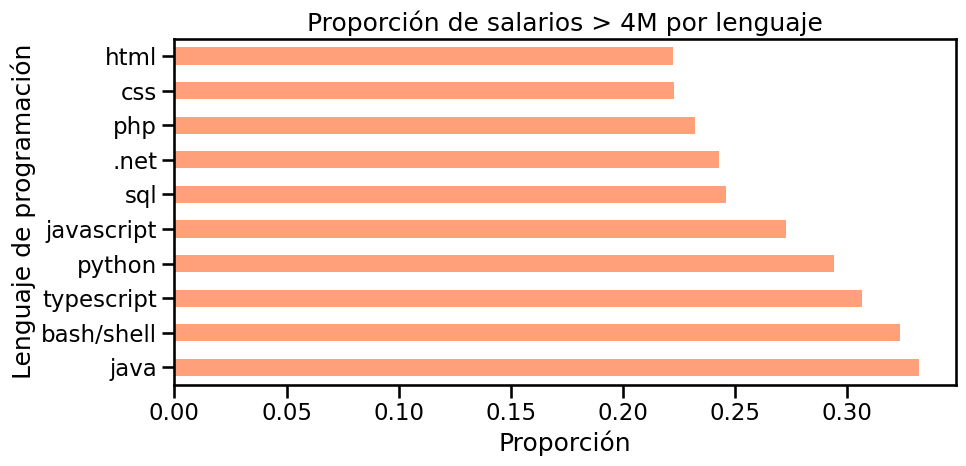

In [ ]:
threshold = 4000000
probs = df_top10.groupby('programming_language')['salary_monthly_NETO']\
    .apply(lambda x: (x > threshold).mean())\
    .sort_values(ascending=False)

plt.figure(figsize=(10, 5))
probs.plot(kind='barh', color='lightsalmon')
plt.title('Proporción de salarios > 4M por lenguaje')
plt.xlabel('Proporción')
plt.ylabel('Lenguaje de programación')
plt.tight_layout()

A partir del grafico anterior podemos ver que Java, Bash/Shell, Typescript y Python son los únicos que superan el 25% de probabilidad de ganar mas de $4.000.000. Donde Java y Bash/Shell llegan a super el 30% de probabilidad.

A continuacion comparamos probabilidades para obtener un resultado numerico que nos ayude a responder la pregunta.

In [ ]:
avg_salary = df_top10[salary_col].mean()
avg_salary

np.float64(3370804.132766825)

In [ ]:
prob_above_avg = len(df_top10[df_top10[salary_col] >= avg_salary]) / len(df_top10) 
prob_above_avg 

0.3960376808779256

Obtuvimos la probabilidad de ganar mas que el promedio, ahora veamos como se relaciona esta con cada lenguaje.

In [ ]:
df_top10['is_above_avg'] = df_top10[salary_col] > avg_salary

prob_cond = df_top10.groupby('programming_language')['is_above_avg'].mean().sort_values(ascending=False) 

print(prob_cond)

programming_language
java          0.487734
bash/shell    0.441982
typescript    0.434783
python        0.422018
javascript    0.402029
.net          0.374477
sql           0.372251
html          0.347009
php           0.341772
css           0.332880
Name: is_above_avg, dtype: float64


Ahora quiero comparar entre los 4 lenguajes con una mediana mas alta.

In [124]:
p = prob_cond.to_dict()

ratio1 = p['java'] / p['typescript']
ratio2 = p['typescript'] / p['python']
ratio3 = p['bash/shell'] / p['typescript']
ratio4 = p['bash/shell'] / p['python']

print(f'El ratio entre java y typescript es: {ratio1}')
print(f'El ratio entre typescript y python es: {ratio2}')
print(f'El ratio entre bash/shell y typescript es: {ratio3}')
print(f'El ratio entre python y bash/shell es: {ratio4}')


El ratio entre java y typescript es: 1.1217893217893218
El ratio entre typescript y python es: 1.0302457466918713
El ratio entre bash/shell y typescript es: 1.0165580182529337
El ratio entre python y bash/shell es: 1.0473045745706027


Saber Java aumenta en un 13% las chances de ganar mas que el promedio ($3.300.000) que saber typescript.

Si comparamos typescript con python y bash/shell obtenemos resultados equivalentes de aproximadamente 1, es decir que sus probabilidades son equivalentes y no aportan informacion relevante.

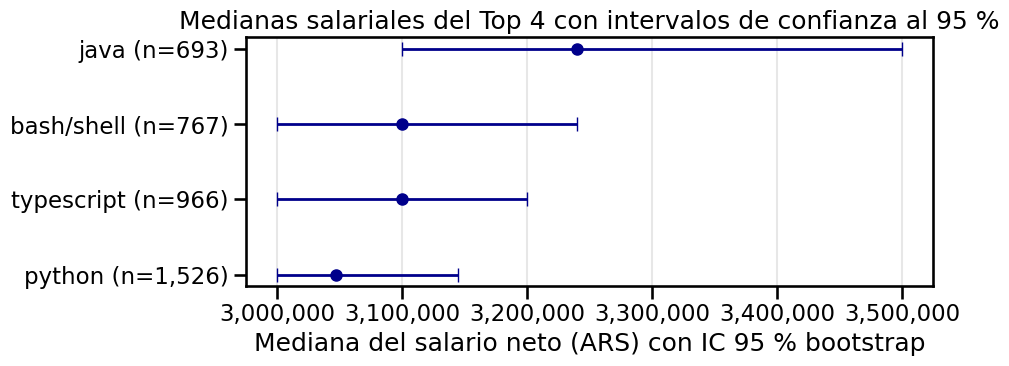

In [ ]:
from scipy.stats import bootstrap

top4 = ['java', 'typescript', 'bash/shell', 'python']

results = {}
for lang in top4:
    salaries = df_top10.loc[df_top10['programming_language'] == lang, salary_col].values
    res = bootstrap(
        (salaries,),
        np.median,
        n_resamples=10_000,
        confidence_level=0.95,
        method='percentile',
        random_state=42,
    )
    results[lang] = {
        'median': np.median(salaries),
        'ci_low': res.confidence_interval.low,
        'ci_high': res.confidence_interval.high,
        'n': len(salaries),
    }

fig, ax = plt.subplots(figsize=(10, 4))
langs_sorted = sorted(top4, key=lambda l: results[l]['median'])

for i, lang in enumerate(langs_sorted):
    r = results[lang]
    ax.errorbar(
        r['median'], i,
        xerr=[[r['median'] - r['ci_low']], [r['ci_high'] - r['median']]],
        fmt='o', color='darkblue', capsize=5, markersize=8, lw=2,
    )

ax.set_yticks(range(len(langs_sorted)))
ax.set_yticklabels([f"{l} (n={results[l]['n']:,})" for l in langs_sorted])
ax.set_xlabel('Mediana del salario neto (ARS) con IC 95 % bootstrap')
ax.set_title('Medianas salariales del Top 4 con intervalos de confianza al 95 %')
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusión

**¿Cuáles son los lenguajes de programación asociados a los mejores salarios?**

Luego de hacer todo el análisis previo podemos concluir que:

1. **La distribución de salarios es asimétrica positiva (sesgada hacia la derecha).** El histograma muestra una concentración de observaciones en el rango de \$1.500.000 a \$3.500.000 y una cola derecha extensa que se prolonga hasta los \$10.000.000. Esto se refleja en los boxplots: la cola derecha es notablemente más larga, con numerosos valores atípicos. Del lado izquierdo no se observan outliers, aunque esto refleja el filtro de salario mínimo aplicado en pasos previos del pipeline más que una propiedad intrínseca de los datos. Dada esta asimetría, la **mediana** es un estimador de tendencia central más robusto que la media y es la métrica que privilegiamos en el análisis.

2. **Java es el lenguaje con el estimador puntual más alto** en mediana
   ($3.24M ARS) y en P(salario > 4M) (~32%). Sin embargo, el forest plot
   bootstrap muestra que su IC al 95% se solapa con el de los otros tres
   lenguajes del Top 4, por lo que su liderazgo, aunque consistente en
   todos los estimadores puntuales, no constituye una separación
   estadísticamente robusta.

3. **TypeScript, Bash/Shell y Python forman un cluster estadísticamente
   indistinguible** en mediana salarial: sus IC bootstrap se solapan
   completamente, con un piso común cercano a $3M ARS. Las diferencias
   en los estimadores puntuales (5k–50k entre ellos) son menores a la
   incertidumbre muestral. TypeScript se diferencia más claramente en
   métricas de cola (lidera el Top 10% con $6.3M) y Bash/Shell en
   P(salario > 4M).

4. **Python queda en tercer lugar**, con una mediana idéntica a Bash/Shell (\$3.000.000) pero medias y probabilidades algo menores. La comparación de ratios entre TypeScript, Python y Bash/Shell muestra que las probabilidades condicionales de superar el salario promedio son equivalentes (ratios ≈ 1), confirmando que la diferencia entre estos tres no es estadísticamente apreciable.

5. **Java aumenta en un 13% (relativo) la probabilidad de superar el salario promedio (~\$3.300.000 ARS) respecto de TypeScript** ($P(>\bar{x}\,|\,\text{Java}) / P(>\bar{x}\,|\,\text{TypeScript}) \approx 1{,}13$). En términos absolutos esto corresponde a una diferencia de aproximadamente 4 puntos porcentuales — no es una brecha enorme, pero es consistente con que Java domina todas las métricas analizadas.

6. **La distribución de P(salario > \$4M) revela dos grupos claros:**
    - **Grupo alto** (>27%): Java, Bash/Shell, TypeScript, Python.
    - **Grupo bajo** (~22–26%): JavaScript, SQL, .NET, PHP, CSS, HTML.
    Esta partición complementa el ranking por mediana y refuerza la conclusión: los cuatro lenguajes del grupo alto son los asociados a los mejores salarios.

### Ranking final

Una interpretación honesta del análisis combinado:

🥇 **Java** — líder en todos los estimadores puntuales, aunque con IC
solapado al resto del Top 4.

🥈 **Cluster {TypeScript, Bash/Shell, Python}** — estadísticamente
indistinguibles entre sí en mediana; se diferencian sutilmente en
métricas de cola.

🥉 **Grupo bajo** (JavaScript, SQL, .NET, PHP, CSS, HTML) — claramente
separados del cluster anterior tanto por mediana como por P(>4M).

### Limitaciones

Este análisis se basa en la **asociación** entre lenguaje y salario, no en una relación causal. Los lenguajes con mejores salarios pueden estar correlacionados con factores no observados como el seniority promedio de quienes los usan, el sector de la industria, el tipo de empresa o la modalidad de contratación. Además, los resultados están condicionados al filtro de salarios aplicado previamente al análisis (a auditar en una iteración futura) y a la auto-selección de la muestra de la encuesta Sysarmy, que no es representativa de la población total de profesionales del rubro en Argentina.

# Explorando relaciones: densidades y múltiples variables
Buscamos qué herramientas visuales y estadísticas ayudan a descubrir patrones y asociaciones entre salario, edad, seniority, modalidad y nivel de estudios.

Las columnas que consideramos relevantes son:

1. Categorias numéricas:
    - `'salary_monthly_BRUTO'` y `'salary_monthly_NETO'`: Las categorías principales del análisis. Aunque inicialmente el salario neto parece bastar para el análisis, no se descarta que el salario bruto proporcione información complementaria relevante.
    - `'profile_age'`:
2. Variables categoricas:
    - `'work_seniority'`:
    - `'work_work_modality'`:

- `'profile_age'`: permite explorar la relación edad–salario y controlar por experiencia
- `'work_seniority'`: nivel de seniority (Junior/SemiSr/Sr), variable categórica clave para segmentar
- `'work_work_modality'`: modalidad (Remoto/Presencial/Híbrido), relevante para diferencias salariales post-pandemia

In [125]:
relevant_columns_pt2=['salary_monthly_NETO',
                      'salary_monthly_BRUTO',
                      'profile_age',
                      'work_seniority',
                      'work_work_modality'
                      ]
salary_br = 'salary_monthly_BRUTO'
age = 'profile_age'
seniority = 'work_seniority'
modality = 'work_work_modality'

In [ ]:
df2 = df1.dropna(subset=relevant_columns_pt2)
print(f"Filas tras eliminar NaN: {len(df2):,}")

Filas tras eliminar NaN: 4,219


### Exploración previa de la edad

Antes de definir el filtro de edad inspeccionamos su distribución y los valores
extremos. La idea es identificar valores implausibles (típicamente errores de
carga) en lugar de aplicar cortes arbitrarios basados en categorías legales que
pueden estar descartando datos válidos.

Estadísticos de edad (antes de filtrar):
count    4219.000000
mean       37.590898
std        19.762218
min        16.000000
25%        31.000000
50%        36.000000
75%        43.000000
max       999.000000
Name: profile_age, dtype: float64


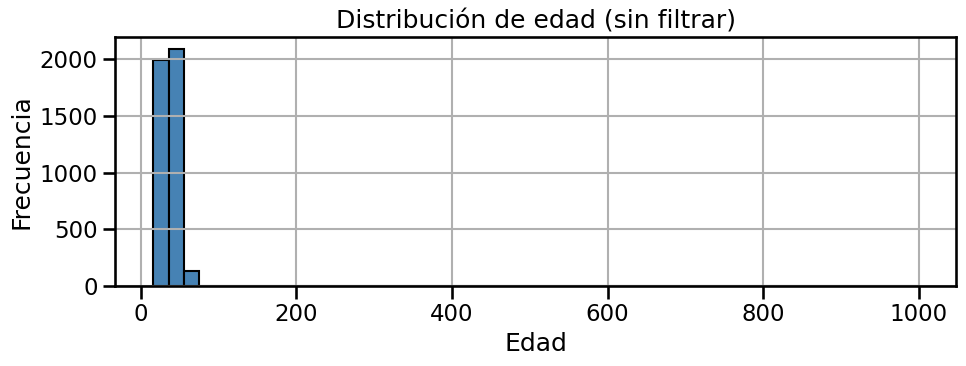


10 valores más bajos:
[np.int64(16), np.int64(19), np.int64(19), np.int64(20), np.int64(20), np.int64(20), np.int64(20), np.int64(20), np.int64(20), np.int64(20)]

10 valores más altos:
[np.int64(68), np.int64(68), np.int64(69), np.int64(70), np.int64(70), np.int64(73), np.int64(75), np.int64(99), np.int64(666), np.int64(999)]


In [ ]:
print("Estadísticos de edad (antes de filtrar):")
print(df2[age].describe())

fig, ax = plt.subplots(figsize=(10, 4))
df2[age].hist(bins=50, ax=ax, edgecolor='black', color='steelblue')
ax.set_xlabel('Edad')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de edad (sin filtrar)')
plt.tight_layout()
plt.show()

print("\n10 valores más bajos:")
print(sorted(df2[age].dropna().values)[:10])
print("\n10 valores más altos:")
print(sorted(df2[age].dropna().values)[-10:])

La exploración confirma que el extremo inferior de la distribución está bien
acotado por la edad laboral mínima (mín = 16), mientras que el extremo superior
contiene valores claramente erróneos (99, 666, 999) separados por un gap del
último valor plausible (75).

A partir de la exploración aplicamos un filtro basado en los datos:

- **Cota inferior**: descartamos edades menores a **16 años**. La edad laboral
  mínima en Argentina es 16 (Ley 26.390)
- **Cota superior**: descartamos edades mayores a **80 años**. Existen
  profesionales activos a edades avanzadas, pero valores por encima de este
  umbral son extremadamente raros y más probablemente reflejan errores de carga.

Esta aproximación es más permisiva que un corte rígido en 18–65 años y conserva
información válida sobre profesionales muy jóvenes o seniors que un filtro
basado en categorías legales habría descartado.

In [ ]:
AGE_MIN, AGE_MAX = 16, 80

before = len(df2)
df2 = df2[(df2[age] >= AGE_MIN) & (df2[age] <= AGE_MAX)]
after = len(df2)

print(f"Filtro de edad [{AGE_MIN}, {AGE_MAX}]:")
print(f"  Filas antes:    {before:,}")
print(f"  Filas después:  {after:,}")
print(f"  Eliminadas:     {before - after:,}  ({(before - after) / before * 100:.2f}%)")

print(f"\nEstadísticos de edad tras filtrar:")
print(df2[age].describe())

Filtro de edad [16, 80]:
  Filas antes:    4,219
  Filas después:  4,216
  Eliminadas:     3  (0.07%)

Estadísticos de edad tras filtrar:
count    4216.000000
mean       37.199241
std         8.763353
min        16.000000
25%        31.000000
50%        36.000000
75%        43.000000
max        75.000000
Name: profile_age, dtype: float64


In [ ]:
# Consistencia: el neto no puede superar al bruto
before = len(df2)
df2_clean = df2[df2[salary_br] >= df2[salary_col]].copy()
print(f"Filas con neto > bruto eliminadas: {before - len(df2_clean):,} "
      f"({(before - len(df2_clean)) / before * 100:.2f}%)")

Filas con neto > bruto eliminadas: 101 (2.50 %)


## Densidad conjunta
Estudiamos cómo se distribuyen los datos cruzando variables: una categórica × categórica (modalidad × seniority) y las numéricas entre sí (salario, edad).

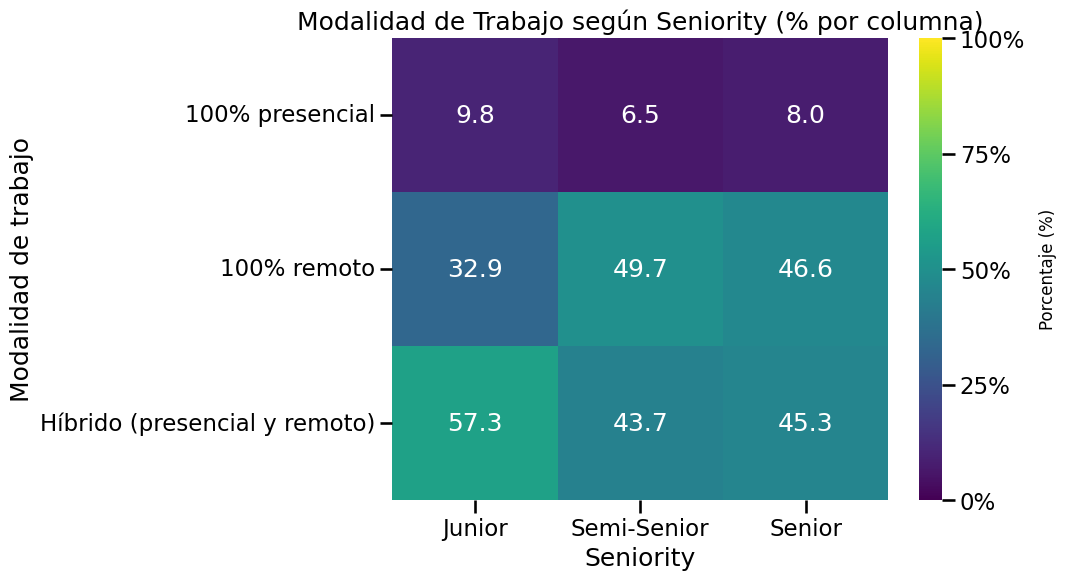

In [131]:
plt.figure(figsize=(8, 6))

ax = sns.heatmap(pd.crosstab(df2_clean[modality], df2_clean[seniority], normalize='columns') * 100,
            annot=True,
            fmt='.1f',
            vmin=0, vmax=100,
            cmap='viridis'
            )

colorbar = ax.collections[0].colorbar
colorbar.set_label('Porcentaje (%)', fontsize=12, labelpad=10)
colorbar.set_ticks([0, 25, 50, 75, 100])
colorbar.set_ticklabels(['0%', '25%', '50%', '75%', '100%'])

plt.title('Modalidad de Trabajo según Seniority (% por columna)')
plt.xlabel('Seniority')
plt.ylabel('Modalidad de trabajo')
plt.show()

A partir del gráfico observamos dos patrones:

1. **La modalidad presencial es minoritaria en todos los niveles de seniority**
   (entre 6.7 % y 10.7 %), confirmando la consolidación del trabajo a distancia
   post-pandemia en el sector IT.

2. **La distribución entre modalidades remota e híbrida varía sistemáticamente
   con el seniority**: los perfiles Junior se inclinan claramente al híbrido
   (56.5 %) sobre el remoto (32.8 %), mientras que Semi-Senior y Senior
   prefieren el remoto puro (50.3 % y 46.6 % respectivamente). Una interpretación
   plausible es que los perfiles junior valoran el contacto presencial para
   formación y construcción de red profesional, mientras que los perfiles más
   senior ya consolidaron su capital social y priorizan la flexibilidad.

### Análisis Variables numéricas

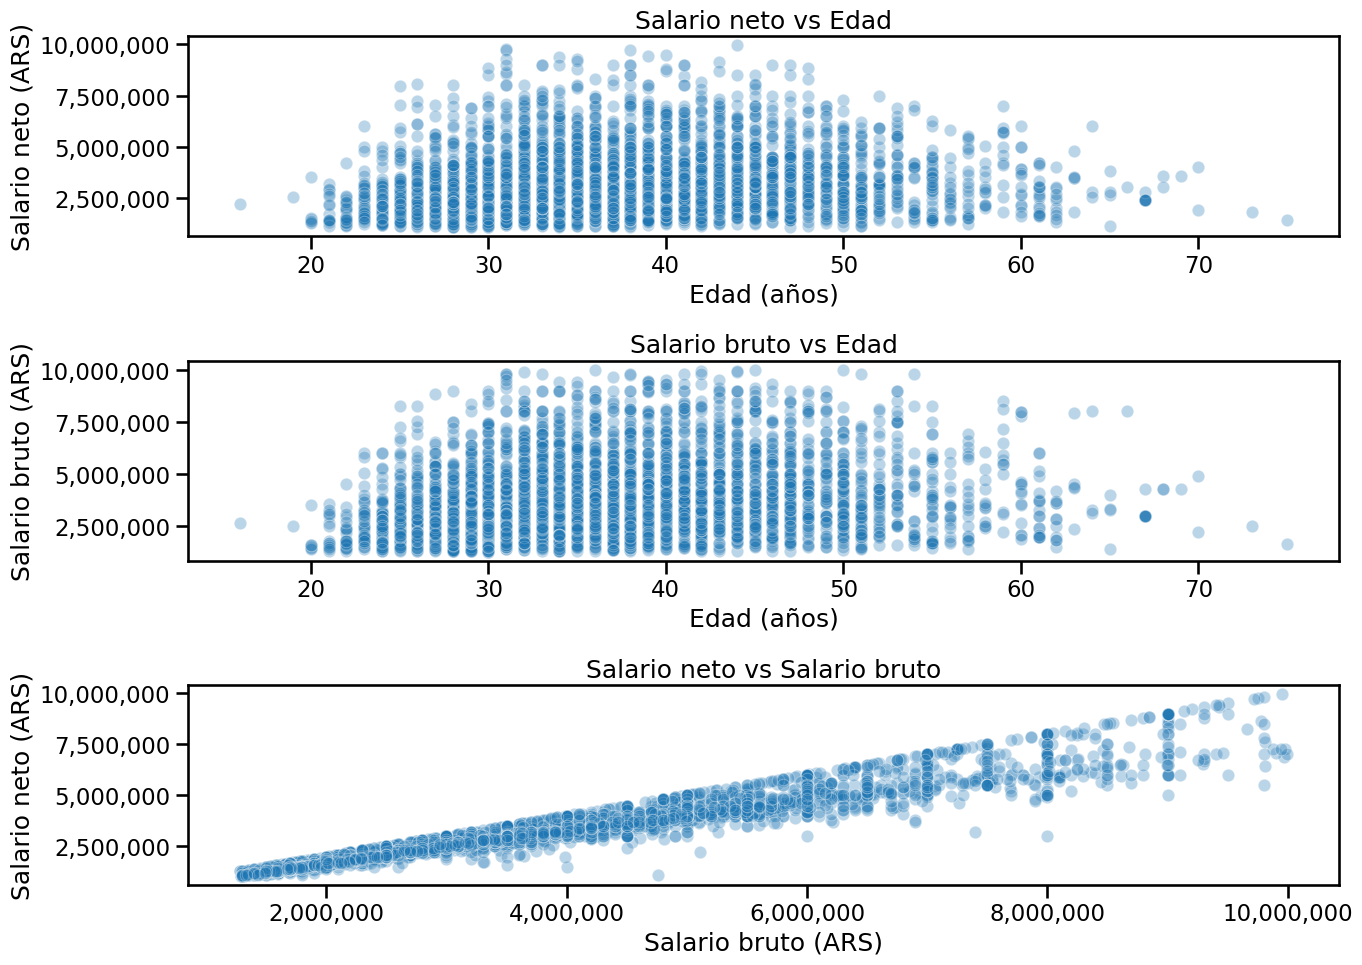

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

df_final = df2_clean[df2_clean[salary_br] >= df2_clean[salary_col]]

sns.scatterplot(data=df_final, x=age, y=salary_col,
                ax=axes[0], alpha=0.3)

axes[0].set_title('Salario neto vs Edad')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Salario neto (ARS)')
axes[0].ticklabel_format(style='plain', axis='y')


sns.scatterplot(data=df_final, x=age, y=salary_br,
                ax=axes[1], alpha=0.3)

axes[1].set_title('Salario bruto vs Edad')
axes[1].set_xlabel('Edad (años)')
axes[1].set_ylabel('Salario bruto (ARS)')
axes[1].ticklabel_format(style='plain', axis='y')


sns.scatterplot(data=df_final, x=salary_br, y=salary_col,
                ax=axes[2], alpha=0.3)

axes[2].set_title('Salario neto vs Salario bruto')
axes[2].set_xlabel('Salario bruto (ARS)')
axes[2].set_ylabel('Salario neto (ARS)')
axes[2].ticklabel_format(style='plain', axis='x')
axes[2].ticklabel_format(style='plain', axis='y')

for ax in axes:
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

No se observa una relación lineal fuerte entre edad y salario, pero sí un patrón no-monótono: el rango y la varianza salarial crecen con la edad hasta los ~45 años y luego se estabilizan o decrecen ligeramente.

In [ ]:
from scipy.stats import pearsonr, spearmanr

r_pearson, p_pearson = pearsonr(df2_clean[age], df2_clean[salary_col])
r_spearman, p_spearman = spearmanr(df2_clean[age], df2_clean[salary_col])

print(f"Edad vs Salario NETO:")
print(f"  Pearson  r = {r_pearson:.3f}  (p = {p_pearson:.2e})")
print(f"  Spearman ρ = {r_spearman:.3f}  (p = {p_spearman:.2e})")

Edad vs Salario NETO:
  Pearson  r = 0.158  (p = 1.72e-23)
  Spearman ρ = 0.216  (p = 8.61e-43)


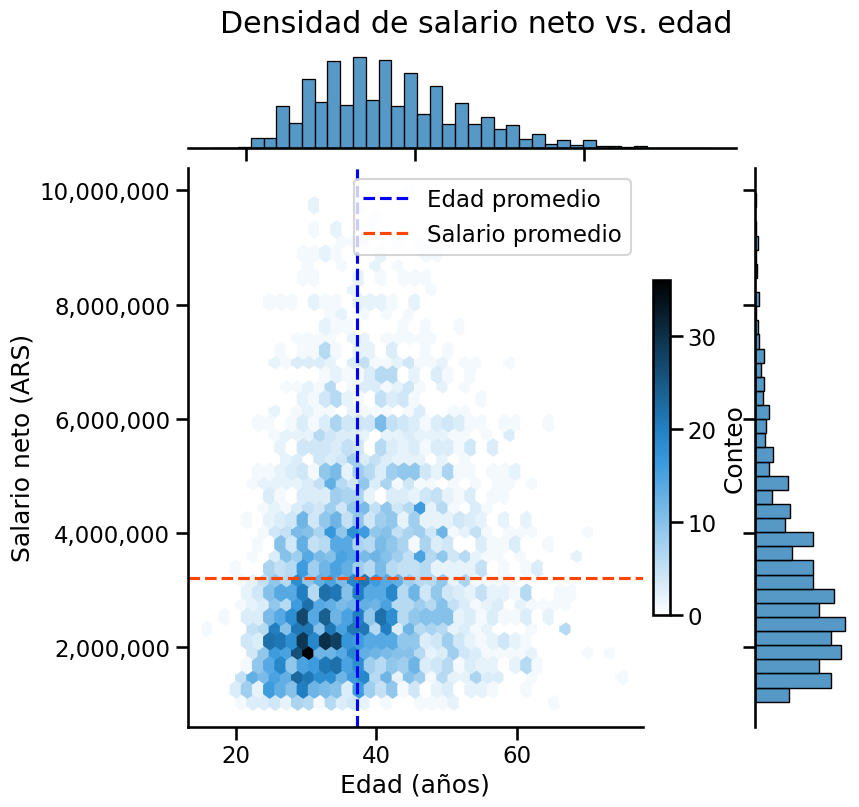

In [ ]:

h = sns.jointplot(data=df2_clean,
                  x=age,
                  y=salary_col,
                  kind='hex',
                  height=8,

                  )

hb = h.ax_joint.collections[0]
cb = h.fig.colorbar(hb, ax=h.ax_joint, pad=0.02, shrink=0.6)
cb.set_label('Conteo')

h.ax_joint.axvline(df2_clean[age].mean(), color='blue', linestyle='--', label='Edad promedio')
h.ax_joint.axhline(df2_clean[salary_col].mean(), color='orangered', linestyle='--', label='Salario promedio')
h.ax_joint.legend()

h.ax_joint.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

h.set_axis_labels("Edad (años)", "Salario neto (ARS)")
h.fig.suptitle('Densidad de salario neto vs. edad', y=1.02)
plt.show()

El hexbin muestra que la masa principal de la muestra se concentra en
profesionales de 28–32 años con salarios entre 1.8M y 2.2M ARS. No se observan
altos salarios entre los menores de 30 (cuadrante superior izquierdo vacío),
mientras que los salarios más altos aparecen recién a partir de los 35 años.
Esto es consistente con el efecto del seniority/experiencia sobre los ingresos.

Adicionalmente, los salarios muy altos (por encima de 6M ARS) son escasos en
toda la muestra independientemente de la edad, reflejando el sesgo positivo
de la distribución salarial. La estructura general muestra un patrón en forma
de abanico: la varianza salarial crece con la edad hasta los ~45 años y luego
se estabiliza.

### Análisis variables categóricas y numéricas

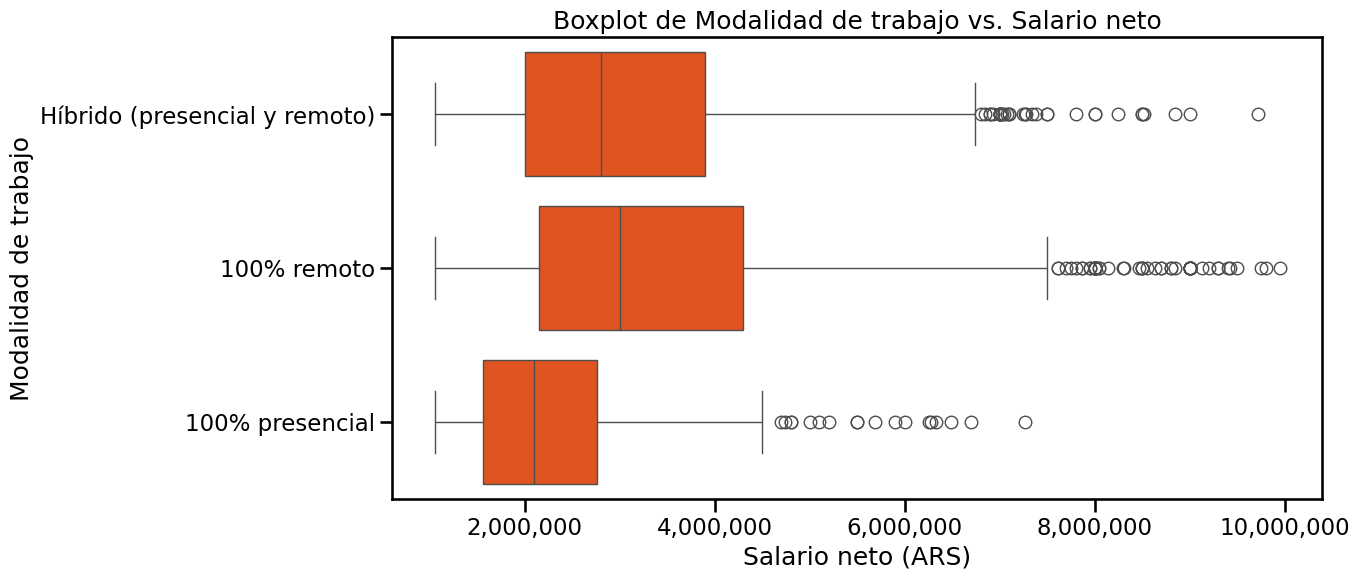

In [135]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df2_clean,
            x=salary_col,
            y=modality,
            color='orangered'
            )

plt.title('Boxplot de Modalidad de trabajo vs. Salario neto')
plt.xlabel("Salario neto (ARS)")
plt.ylabel("Modalidad de trabajo")
plt.ticklabel_format(style='plain', axis='x')
plt.gca().xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.show()

El boxplot evidencia un patrón claro en las medianas salariales según
modalidad de trabajo:

- **100% presencial** presenta la mediana salarial más baja (~2.0M ARS) y
  también la menor dispersión, con un IQR comprimido y outliers que llegan
  hasta los 6.5M ARS.
- **Híbrido** y **100% remoto** tienen medianas similares (~2.7M y ~3.0M ARS
  respectivamente), con IQRs que se solapan considerablemente. La diferencia
  entre estas dos modalidades es modesta (~10 % en mediana), mientras que la
  diferencia entre presencial y las otras dos es marcada (~33 %).
- Los tres grupos exhiben colas largas hacia salarios altos, consistente con
  el sesgo positivo característico de las distribuciones salariales.

Una hipótesis a explorar es que la modalidad remota correlaciona con
contratos con empresas extranjeras, que ofrecen salarios en dólares y por
tanto mayores en ARS al convertirlos. Sin embargo, este análisis no permite
distinguir esa explicación de otras igualmente plausibles por ejemplo, que
perfiles más senior o con habilidades más demandadas tengan mayor poder de
negociación para conseguir modalidad remota.

Combinando este resultado con el heatmap de contingencia anterior
(seniority × modalidad) emerge un patrón coherente: las modalidades remota
e híbrida no solo son las más frecuentes, sino que también se asocian a
salarios más altos, particularmente en comparación con el trabajo
presencial.

## Asociación: ¿el salario bruto aporta información distinta del neto?
Evaluamos si conviene descartar el salario bruto, midiendo su correlación con el neto y la estabilidad del ratio neto/bruto.

### Asociación entre salario BRUTO y salario NETO

Una de las preguntas del ejercicio es si conviene eliminar la columna de salario
bruto del análisis para simplificarlo. Esto se justifica si y solo si BRUTO no
aporta información sustantivamente distinta de NETO, lo cual se puede evaluar a
través de la correlación entre ambas variables y la estabilidad del ratio
NETO / BRUTO.

A partir del scatterplot anterior se aprecia una relación claramente directa
entre ambas. Cuantificamos esta asociación con dos medidas complementarias:

- **Coeficiente de Pearson** (mide correlación lineal, sensible a valores extremos).
- **Coeficiente de Spearman** (basado en rangos, robusto a no-linealidades y
  apropiado para distribuciones sesgadas como las salariales).

In [ ]:
r_p, p_p = pearsonr(df2_clean[salary_br], df2_clean[salary_col])
r_s, p_s = spearmanr(df2_clean[salary_br], df2_clean[salary_col])

ratio = df2_clean[salary_col] / df2_clean[salary_br]

print(f"Correlación NETO ↔ BRUTO:")
print(f"  Pearson  r = {r_p:.4f}  (p = {p_p:.2e})")
print(f"  Spearman ρ = {r_s:.4f}  (p = {p_s:.2e})")
print(f"\nRatio NETO / BRUTO:")
print(f"  Media    = {ratio.mean():.3f}")
print(f"  Mediana  = {ratio.median():.3f}")
print(f"  Desvío   = {ratio.std():.3f}")

Correlación NETO ↔ BRUTO:
  Pearson  r = 0.9617  (p = 0.00e+00)
  Spearman ρ = 0.9791  (p = 0.00e+00)

Ratio NETO / BRUTO:
  Media    = 0.842
  Mediana  = 0.830
  Desvío   = 0.084


**Interpretación:**

- Ambos coeficientes son muy altos ($r = 0.96$, $\rho = 0.98$), confirmando una
  asociación lineal y monótona prácticamente perfecta. La pequeña diferencia
  ($\rho > r$) sugiere una no-linealidad leve en los salarios altos, donde la
  dispersión aumenta —consistente con el patrón "abanico" observado en el
  scatterplot.

- El ratio NETO / BRUTO se concentra en torno a 0.83–0.84 con un desvío bajo
  (0.085), lo que implica que en la mayoría de los casos los trabajadores
  retienen entre el 75 % y el 93 % del salario bruto. Esto refleja una tasa
  efectiva de descuentos (impuestos + aportes) de aproximadamente **15 %–17 %**,
  estable a lo largo de la muestra.

**Conclusión:** El salario BRUTO no aporta información sustantivamente distinta
de NETO en esta muestra — la relación es esencialmente determinista (salvo por
variación menor en la tasa de descuentos individual). Por lo tanto, **podemos
eliminar la columna `salary_monthly_BRUTO` del análisis sin pérdida apreciable
de información**, simplificando los modelos y análisis posteriores.

## Densidad condicional: salario según nivel de estudios
Comparamos la distribución del salario neto entre los dos niveles de estudio más numerosos (Universitario y Terciario), con histogramas y medidas de centralidad y dispersión.

Estudiamos la distribución del salario neto en función del nivel de estudios.
Primero inspeccionamos la frecuencia de cada nivel para identificar las
subpoblaciones más numerosas.

In [137]:
df2_clean['profile_studies_level'].value_counts()

profile_studies_level
Universitario               944
Terciario                   204
Posgrado/Especialización     88
Maestría                     88
Secundario                   50
Doctorado                    16
Posdoctorado                  6
Name: count, dtype: int64

Seleccionamos los dos niveles más numerosos **Universitario** (n = 980) y
**Terciario** (n = 220) para garantizar suficiente base muestral en cada
grupo. Esto excluye niveles minoritarios (Maestría, Doctorado, etc.) que
tendrían comparaciones menos estables.

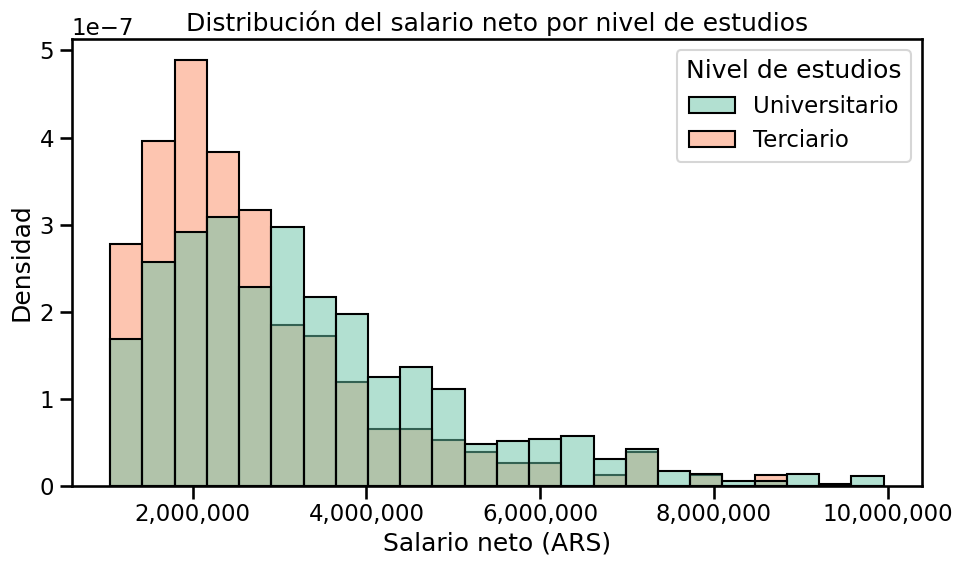

In [138]:
fig, ax = plt.subplots(figsize=(10, 6))

sub_studies = df2_clean[
    df2_clean['profile_studies_level'].isin(['Universitario', 'Terciario'])
]

sns.histplot(
    data=sub_studies,
    x=salary_col,
    hue='profile_studies_level',
    stat='density',
    common_norm=False,   
    palette='Set2',
    ax=ax,
)

ax.set_title('Distribución del salario neto por nivel de estudios')
ax.set_xlabel('Salario neto (ARS)')
ax.set_ylabel('Densidad')
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))


ax.get_legend().set_title('Nivel de estudios')

plt.tight_layout()
plt.show()

Ambas distribuciones presentan sesgo positivo (asimetría hacia la derecha),
típico de las distribuciones salariales. El nivel Universitario muestra
mayor concentración relativa en el rango 2M–3M ARS y una cola derecha más
extendida que llega hasta los 9.5M ARS, mientras que el Terciario presenta
una distribución más uniforme con un techo más bajo (8.5M ARS).

**Nota metodológica:** como el histograma está normalizado independientemente
por grupo (`common_norm=False`), las alturas reflejan **proporciones internas
de cada nivel**, no cantidades absolutas. Que el pico del Universitario sea
más alto en 2M no implica que los universitarios ganen menos — significa
que una mayor proporción de universitarios se concentra en ese rango. Para
responder rigurosamente sobre asociación entre nivel y salario necesitamos
las medidas de centralidad y un test estadístico.

In [ ]:
central = sub_studies.groupby('profile_studies_level')[salary_col].agg(
    media='mean',
    mediana='median',
    P75=lambda x: x.quantile(0.75),
).sort_values(by='media', ascending=False)

display(central.style.format("{:,.0f}"))

,media,mediana,P75
profile_studies_level,,,
Universitario,"3,359,875","3,000,000","4,200,000"
Terciario,"2,684,554","2,321,500","3,200,000"


**El nivel Universitario presenta salarios sistemáticamente mayores que el
Terciario en todas las métricas de centralidad:**

- Media: **+24 %** ($3{,}255{,}527$ vs. $2{,}618{,}223$ ARS)
- Mediana: **+30 %** ($3{,}000{,}000$ vs. $2{,}300{,}000$ ARS)
- Percentil 75: **+30 %** ($4{,}058{,}274$ vs. $3{,}112{,}500$ ARS)

Esto sugiere una asociación positiva entre nivel educativo y salario, al
menos al comparar estos dos niveles. Omitimos la **moda** porque para
variables continuas con respuestas de encuesta su valor refleja
principalmente el patrón de **redondeo subjetivo** de los encuestados
(valores como 2.000.000 o 3.000.000) más que una característica real de
la distribución.

In [ ]:
dispersion = sub_studies.groupby('profile_studies_level')[salary_col].agg(
    desviacion_estandar='std',
    coef_de_variacion=lambda x: x.std() / x.mean() * 100,
    rango=lambda x: x.max() - x.min(),
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25),
    minimo='min',
    maximo='max',
)

display(dispersion.style.format({
    'desviacion_estandar': '{:,.0f}',
    'coef_de_variacion':   '{:.1f} %',
    'rango':               '{:,.0f}',
    'IQR':                 '{:,.0f}',
    'minimo':              '{:,.0f}',
    'maximo':              '{:,.0f}',
}))

,desviacion_estandar,coef_de_variacion,rango,IQR,minimo,maximo
profile_studies_level,,,,,,
Terciario,"1,347,746",50.2 %,"7,421,000","1,408,025","1,079,000","8,500,000"
Universitario,"1,667,023",49.6 %,"8,902,800","2,100,000","1,050,000","9,952,800"


La dispersión es considerable en ambos grupos (coeficiente de variación
≈ 50 %), lo cual es esperable en datos salariales que dependen de múltiples
factores no controlados aquí: seniority, rol específico, sector, modalidad,
contratos con empresas extranjeras, etc. Aun así, las diferencias en
centralidad son consistentes y de magnitud sustantiva (>25 % en todas las
métricas), lo que sugiere una asociación real más allá del ruido.

## Densidad conjunta condicional: edad, salario y seniority
Scatterplot de edad vs. salario coloreado por seniority, para ver cómo la tercera variable estructura la relación.

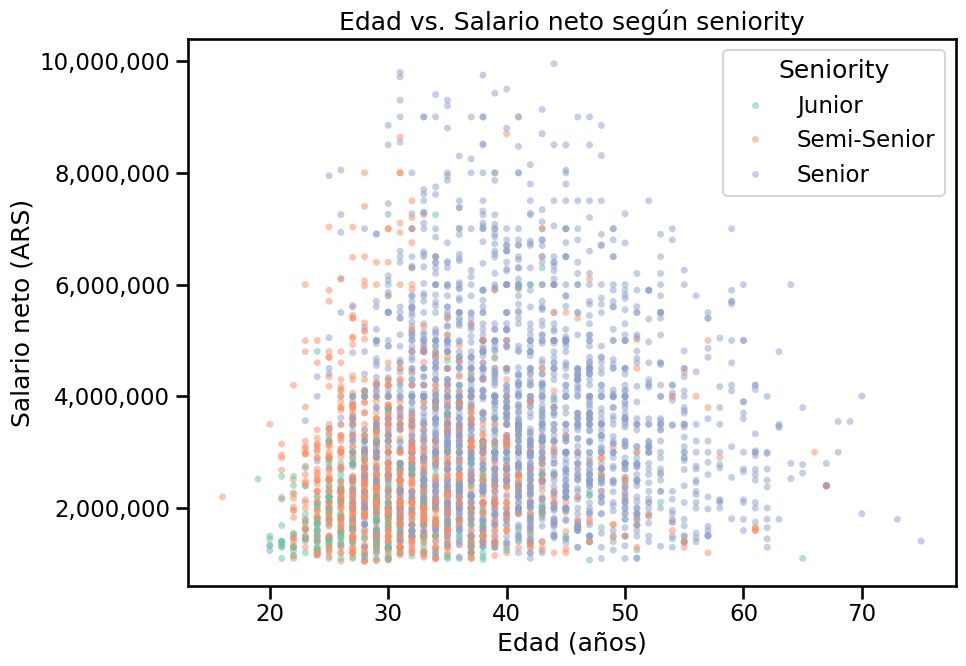

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

seniority_order = ['Junior', 'Semi-Senior', 'Senior'] 

sns.scatterplot(
    data=df2_clean,
    x=age,
    y=salary_col,
    hue=seniority,
    hue_order=seniority_order,
    palette='Set2',
    alpha=0.5,         
    s=25,              
    edgecolor='none',  
    ax=ax,
)

ax.set_title('Edad vs. Salario neto según seniority')
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Salario neto (ARS)')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax.legend(title='Seniority')

plt.tight_layout()
plt.show()

El scatterplot revela varios patrones más allá de la asociación esperada
entre edad, seniority y salario:

1. **Existe un "techo" claro para Juniors**: la mayoría se concentra por
   debajo de los 3M ARS, independientemente de su edad. Esto sugiere que
   el seniority funciona como un umbral salarial efectivo: ser Junior limita
   el techo de ingresos incluso para profesionales de mayor edad.

2. **Los Seniors abarcan todo el rango etario** (desde ~22 hasta 65 años),
   indicando que el seniority no es estrictamente función de la edad. Esto
   es coherente con que el seniority se asigna por experiencia y
   responsabilidades, no por edad cronológica.

3. **A una misma edad coexisten los tres seniorities**: en el rango 30-40
   años se observan Juniors, Semi-Seniors y Seniors simultáneamente.
   Por tanto, la **edad no determina el seniority** — son variables
   correlacionadas pero distintas. Esto refuerza el seniority como predictor
   más fuerte del salario que la edad.

4. **Semi-Seniors ocupan la posición transicional**: sus salarios se
   solapan con los Juniors en el extremo bajo y con los Seniors en el
   extremo medio, pero rara vez alcanzan los salarios superiores (>6M)
   reservados casi exclusivamente a Seniors.

5. **La dispersión salarial dentro de cada nivel es alta**, especialmente
   en Seniors (desde ~1.2M hasta ~9.5M ARS). Esto refleja que el seniority,
   aunque importante, no es el único determinante: factores como el tipo
   de empresa, modalidad, y rol específico contribuyen sustancialmente
   a la varianza salarial intragrupo.

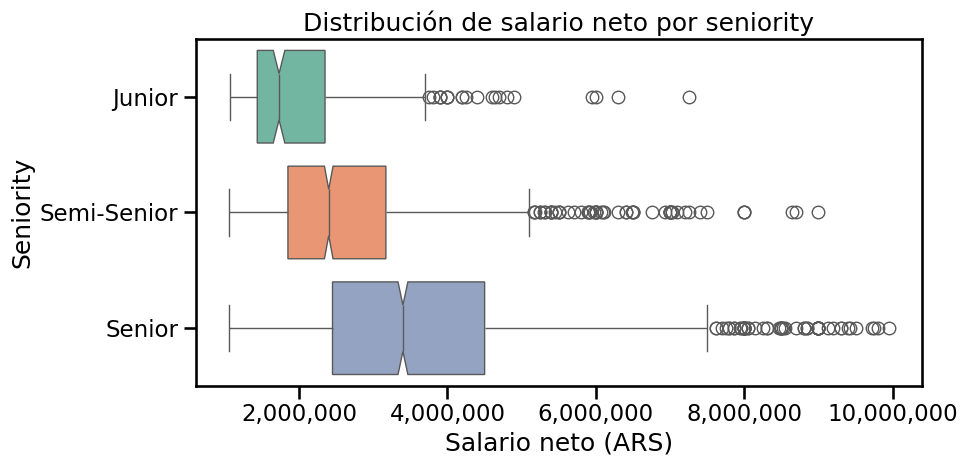

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=df2_clean,
    x=salary_col,
    y=seniority,
    order=seniority_order,
    hue=seniority,              
    hue_order=seniority_order,  
    palette='Set2',
    legend=False,               
    notch=True,
    ax=ax,
)

ax.set_title('Distribución de salario neto por seniority')
ax.set_xlabel('Salario neto (ARS)')
ax.set_ylabel('Seniority')
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()